# 04. Model Development & Evaluation

## Objective
The objective of this notebook is to systematically evaluate, compare, and optimize machine learning models for predicting employee attrition. Using a consistent 5-fold Stratified Cross-Validation framework, we evaluate 5 classification algorithms across 3 class imbalance handling strategies (15 model × strategy combinations total), select the top-performing model based directly on empirical cross-validated evidence, optimize its hyperparameters and decision threshold, and export production-ready artifacts for deployment.

## 1. Environment Setup & Library Imports

### What this cell does:
Imports core dependencies for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), classification algorithms (`sklearn`, `xgboost`, `lightgbm`, `catboost`), imbalance handling (`imblearn`), cross-validation, hyperparameter optimization, and performance metrics. It also initializes and verifies local directory structures (`models/`, `reports/`) for artifact storage.

### Why this step exists:
Centralizing imports and environment configurations guarantees reproducible execution and sets up standardized output locations for saving trained model binaries, metadata, and evaluation figures.

In [9]:
import json
import joblib
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Imbalanced Learning & Evaluation
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

# Set Directories
base_dir = pathlib.Path.cwd().parent
processed_dir = base_dir / "data" / "processed"
arifacts_dir = base_dir / "artifacts"
reports_dir = base_dir / "reports"

for path in [arifacts_dir, reports_dir]:
    path.mkdir(parents=True, exist_ok=True)

print(" Setup complete. Directories verified.")

 Setup complete. Directories verified.


## 2. Load Preprocessed Data Splits & Preprocessing Pipeline

### What this cell does:
Loads the preprocessed training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) data splits generated in the preprocessing pipeline. It then loads the fitted `ColumnTransformer` preprocessing pipeline (`preprocessor.joblib`) and transforms both feature splits into numerical feature arrays.

### Why this step exists:
Applying the exact fitted preprocessing pipeline to both training and test sets ensures consistent categorical encoding, numerical scaling, and missing value imputation across splits, completely preventing data leakage between training and evaluation phases.

In [10]:
# 1. Load Preprocessed Splits (preserves original raw types)
X_train = pd.read_pickle(processed_dir / "X_train.pkl")
X_test = pd.read_pickle(processed_dir / "X_test.pkl")
y_train = pd.read_pickle(processed_dir / "y_train.pkl")["Attrition"]
y_test = pd.read_pickle(processed_dir / "y_test.pkl")["Attrition"]

# 2. Load Fitted Preprocessing Pipeline
preprocessor = joblib.load(arifacts_dir / "preprocessor.joblib")

# 3. Transform Feature Sets
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f" Data successfully loaded!")
print(f"X_train shape: {X_train_transformed.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test_transformed.shape}  | y_test shape:  {y_test.shape}")

 Data successfully loaded!
X_train shape: (1176, 49) | y_train shape: (1176,)
X_test shape:  (294, 49)  | y_test shape:  (294,)


## 3. Class Imbalance Analysis & Cross-Validation Strategy Setup

### What this cell does:
Calculates the class imbalance ratio (~80/20 negative-to-positive ratio, or approximately 5.25 negative cases for every positive attrition case) in the training data, configures a 5-fold Stratified Cross-Validation splitter (`StratifiedKFold`), and defines a standardized evaluation helper function (`evaluate_models_cv`) to evaluate candidate models across multiple metrics (ROC-AUC, F1-Score, Recall, Precision, Accuracy).

### Why this step exists:
- **Preserving Class Balance across Folds:** Because employee attrition exhibits significant class imbalance (~80/20 split), using `StratifiedKFold` ensures every validation fold retains the exact target class distribution.
- **Fair & Reusable Evaluation:** The `evaluate_models_cv` utility standardizes cross-validation scoring across all experiments, ensuring fair comparisons across all 15 model-strategy combinations.
- **Parameter Calculation:** Calculating the exact negative-to-positive ratio provides the required weighting factor (`scale_pos_weight`) for algorithms like XGBoost.

In [11]:
# Calculate class balance ratio for class_weight / scale_pos_weight tuning
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f" Class imbalance ratio (Negative / Positive): {ratio:.2f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_models_cv(models_dict, X, y, cv_strategy):
    """Utility to evaluate multiple models using 5-Fold Stratified Cross-Validation."""
    results = []
    scoring = ['roc_auc', 'f1', 'recall', 'precision', 'accuracy']
    
    for name, model in models_dict.items():
        cv_res = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)
        
        results.append({
            'Model': name,
            'ROC-AUC': cv_res['test_roc_auc'].mean(),
            'F1-Score': cv_res['test_f1'].mean(),
            'Recall': cv_res['test_recall'].mean(),
            'Precision': cv_res['test_precision'].mean(),
            'Accuracy': cv_res['test_accuracy'].mean(),
        })
        
    df_res = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
    return df_res

 Class imbalance ratio (Negative / Positive): 5.19


## 4. Experiment 1: Baseline Models (No Imbalance Adjustment)

### What this cell does:
Trains and evaluates 5 diverse classification algorithms—Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost—in their default baseline state without explicit class imbalance adjustments, using 5-fold Stratified Cross-Validation on the transformed training set.

### Why this step exists:
Establishes an unweighted baseline benchmark across linear models, random forests, and gradient boosted decision trees to determine how each algorithm natively handles the ~80/20 class imbalance without weighting or resampling.

In [12]:
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

df_baseline = evaluate_models_cv(baseline_models, X_train_transformed, y_train, cv)
print("=== EXPERIMENT 1: BASELINE MODEL RESULTS ===")
display(df_baseline)

=== EXPERIMENT 1: BASELINE MODEL RESULTS ===


,Model,ROC-AUC,F1-Score,Recall,Precision,Accuracy
0,Logistic Regression,0.839322,0.557578,0.436842,0.779065,0.889459
1,XGBoost,0.799247,0.450855,0.331579,0.737955,0.871594
2,LightGBM,0.798551,0.429790,0.310526,0.718929,0.868193
3,CatBoost,0.826036,0.408330,0.273684,0.900000,0.874995
4,Random Forest,0.806508,0.308620,0.194737,0.866349,0.863952


## 5. Experiment 2: Class-Weighted Models (Cost-Sensitive Learning)

### What this cell does:
Evaluates the same 5 classification algorithms with cost-sensitive class weighting enabled (`class_weight='balanced'` for Logistic Regression, Random Forest, LightGBM; `scale_pos_weight` for XGBoost; `auto_class_weights='Balanced'` for CatBoost), penalizing misclassifications of minority attrition cases inversely proportional to class frequencies.

### Why this step exists:
Tests whether adjusting loss function weights to compensate for the ~80/20 class imbalance improves minority-class detection performance (F1-Score and ROC-AUC) over unweighted baseline models without modifying training sample distributions.

In [13]:
weighted_models = {
    'Logistic Regression (Weighted)': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Random Forest (Weighted)': RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost (Weighted)': XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    'LightGBM (Weighted)': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    'CatBoost (Weighted)': CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0)
}

df_weighted = evaluate_models_cv(weighted_models, X_train_transformed, y_train, cv)
print("=== EXPERIMENT 2: CLASS WEIGHT RESULTS ===")
display(df_weighted)

=== EXPERIMENT 2: CLASS WEIGHT RESULTS ===


,Model,ROC-AUC,F1-Score,Recall,Precision,Accuracy
0,CatBoost (Weighted),0.819422,0.516535,0.436842,0.641943,0.869034
1,XGBoost (Weighted),0.803197,0.503179,0.410526,0.655708,0.869895
2,Logistic Regression (Weighted),0.827739,0.492729,0.736842,0.372610,0.753350
3,LightGBM (Weighted),0.807355,0.492144,0.405263,0.641003,0.867349
4,Random Forest (Weighted),0.806266,0.450586,0.352632,0.652852,0.864771


## 6. Experiment 3: Synthetic Oversampling via SMOTE

### What this cell does:
Evaluates all 5 models combined with Synthetic Minority Over-sampling Technique (SMOTE) inside an `imblearn.pipeline.Pipeline`, generating synthetic minority class samples strictly within each cross-validation training fold.

### Why this step exists:
Tests synthetic oversampling as a third strategy for addressing class imbalance (~80/20 split). Wrapping SMOTE inside an `ImbPipeline` ensures oversampling occurs exclusively within training folds, preventing data leakage into validation folds.

### Key Decision — Rejection of SMOTE for Final Model:
Although SMOTE was evaluated across all 5 models, it was **explicitly rejected** for the final production model. HR datasets contain discrete and categorical attributes (e.g. `JobRole`, `BusinessTravel`, `EducationField`). Synthesizing interpolated rows across categorical feature spaces generates unrealistic synthetic employee profiles and severely distorts probability calibration required for the downstream frontend risk dashboard.

In [14]:
smote_models = {
    'Logistic Regression (SMOTE)': ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(random_state=42, max_iter=1000))]),
    'Random Forest (SMOTE)': ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', RandomForestClassifier(random_state=42))]),
    'XGBoost (SMOTE)': ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', XGBClassifier(random_state=42, eval_metric='logloss'))]),
    'LightGBM (SMOTE)': ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', LGBMClassifier(random_state=42, verbose=-1))]),
    'CatBoost (SMOTE)': ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', CatBoostClassifier(random_state=42, verbose=0))])
}

df_smote = evaluate_models_cv(smote_models, X_train_transformed, y_train, cv)
print("=== EXPERIMENT 3: SMOTE OVER-SAMPLING RESULTS ===")
display(df_smote)

=== EXPERIMENT 3: SMOTE OVER-SAMPLING RESULTS ===


,Model,ROC-AUC,F1-Score,Recall,Precision,Accuracy
0,CatBoost (SMOTE),0.823470,0.527878,0.400000,0.796540,0.885189
1,Logistic Regression (SMOTE),0.827470,0.510893,0.721053,0.397755,0.776329
2,XGBoost (SMOTE),0.805569,0.479558,0.378947,0.677270,0.870750
3,LightGBM (SMOTE),0.806059,0.441442,0.326316,0.734472,0.869892
4,Random Forest (SMOTE),0.813688,0.416855,0.305263,0.712363,0.866484


## 7. Model & Imbalance Strategy Comparison

### What this cell does:
Consolidates cross-validation evaluation results across all 15 model × strategy combinations (5 models × 3 imbalance strategies) into a single summary DataFrame (`df_all`), and plots a bar chart comparing 5-fold CV F1-Scores across models and strategies.

### Why this step exists:
Provides an empirical, evidence-based table and visual comparison to drive model architecture selection and imbalance strategy decisions.

### Key Finding & Model Selection Decision:
- **Key Finding:** Plain baseline Logistic Regression (no class weighting) achieved the highest ROC-AUC (**0.839**) and F1-Score (**0.558**) across all 15 combinations tested—outperforming every class-weighted and SMOTE variant of every model, including all CatBoost configurations.
- **Model Selection Decision:** Logistic Regression was selected as the final architecture to tune via `RandomizedSearchCV` based directly on this cross-validated empirical evidence, rather than relying on theoretical assumptions about complex tree ensemble dominance.

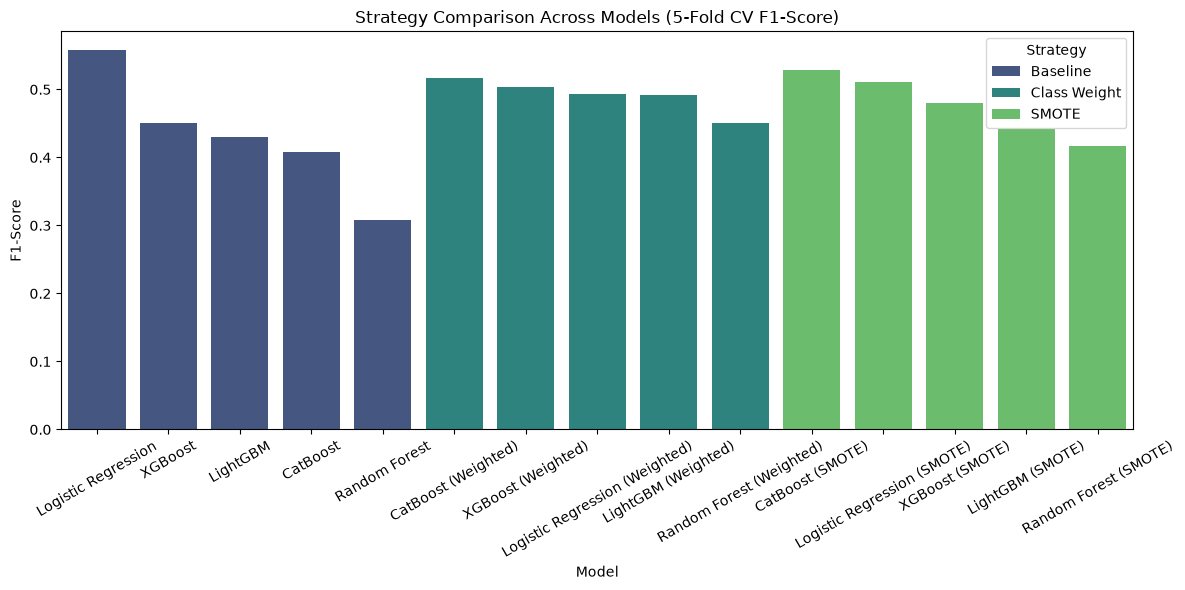

In [15]:
df_all = pd.concat([
    df_baseline.assign(Strategy='Baseline'),
    df_weighted.assign(Strategy='Class Weight'),
    df_smote.assign(Strategy='SMOTE')
], ignore_index=True)

# Plot F1-Score Comparison Across Strategies
plt.figure(figsize=(12, 6))
sns.barplot(data=df_all, x='Model', y='F1-Score', hue='Strategy', palette='viridis')
plt.title('Strategy Comparison Across Models (5-Fold CV F1-Score)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(reports_dir / "strategy_comparison.png", dpi=300)
plt.show()

## 8. Hyperparameter Optimization (RandomizedSearchCV)

### What this cell does:
Executes a `RandomizedSearchCV` over Logistic Regression hyperparameters, searching across inverse regularization strength (`C`), regularization penalty (`penalty`: L1 vs. L2), and class weighting strategy (`class_weight`: `None` vs. `'balanced'`) using 5-fold Stratified Cross-Validation scored on F1.

### Why this step exists:
Optimizes the selected Logistic Regression model to find the ideal balance between regularization strength, feature sparsity, and sensitivity.

### Key Finding & Independent Confirmation:
- The hyperparameter search grid explicitly included both `None` and `'balanced'` class weighting options to let the search independently verify whether class balancing improves performance.
- The search **independently confirmed** that class imbalance did not require special weight handling: the winning parameter set selected `class_weight=None` (no balancing), directly validating the empirical finding from Experiment 1.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# 1. Base Logistic Regression estimator
#    solver='liblinear' supports both l1 and l2 penalties and works well on small/medium datasets
lr_base = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=2000
)

# 2. Define parameter grid — let the search itself confirm whether balancing helps,
#    rather than assuming it does
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 3, 10, 30, 100],   # Inverse regularization strength
    'penalty': ['l1', 'l2'],                       # Regularization type
    'class_weight': [None, 'balanced']              # Let search decide if weighting actually helps
}

# 3. Configure RandomizedSearchCV — same CV strategy and scoring as before, for a fair comparison
search = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# 4. Execute Search
print("Hyperparameter Search for Logistic Regression...")
search.fit(X_train_transformed, y_train)

# 5. Extract Best Model Instance
best_model = search.best_estimator_

print("\n Optimization Complete!")
print(f" Best CV F1-Score: {search.best_score_:.4f}")
print(" Best Parameters Found:")
for k, v in search.best_params_.items():
    print(f"   • {k}: {v}")

Hyperparameter Search for Logistic Regression...

 Optimization Complete!
 Best CV F1-Score: 0.5555
 Best Parameters Found:
   • penalty: l2
   • class_weight: None
   • C: 3


## 9. Out-of-Fold Threshold Selection & Final Test Set Evaluation

### What this cell does:
Computes out-of-fold (OOF) predicted probabilities on the training set using `cross_val_predict`, derives the optimal probability classification threshold (`optimal_threshold`) that maximizes the F1-Score on out-of-fold training predictions, and then evaluates the tuned model on the unseen test set *exactly once* using this locked threshold. It prints final test metrics (ROC-AUC, F1-Score, classification report) and visualizes the Precision-Recall curve alongside the test set confusion matrix.

### Why this step exists & Critical Methodological Safeguard:
- **Preventing Threshold-Leakage:** The classification threshold (`optimal_threshold`) is derived strictly from out-of-fold training set predictions (`cross_val_predict`). The test set is **never touched or inspected** during threshold selection.
- **Unbiased Generalization Performance:** The test set is evaluated exactly once after fixing `optimal_threshold`. This strict operational separation eliminates threshold-leakage and test set overfitting, ensuring reported test performance metrics reflect true generalization ability.

🎯 Optimal Probability Threshold (from training CV, not test set): 0.388

=== FINAL TEST SET PERFORMANCE (Tuned Logistic Regression) ===
ROC-AUC Score: 0.8079

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.90      0.93      0.91       247
    Left (1)       0.55      0.45      0.49        47

    accuracy                           0.85       294
   macro avg       0.73      0.69      0.70       294
weighted avg       0.84      0.85      0.85       294



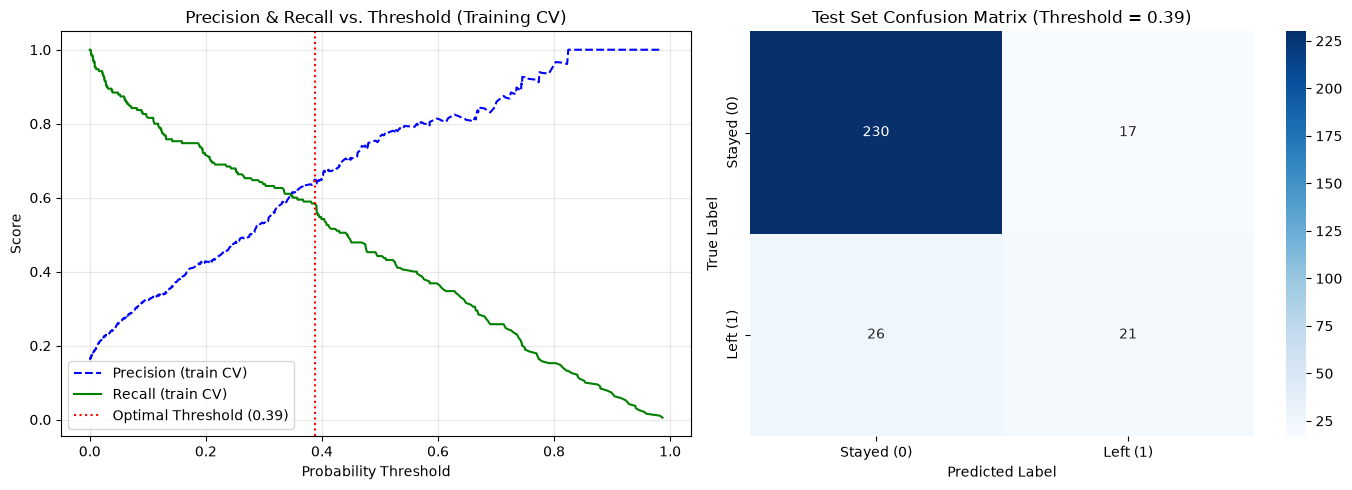

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, f1_score
)

# 1. Get out-of-fold predicted probabilities on TRAINING data only — this is the fix.
#    The threshold is chosen using only training-fold predictions, never touching y_test.
y_train_oof_probs = cross_val_predict(
    best_model, X_train_transformed, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_oof_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"🎯 Optimal Probability Threshold (from training CV, not test set): {optimal_threshold:.3f}")

# 2. NOW touch the test set — exactly once, with the threshold already locked in
y_probs = best_model.predict_proba(X_test_transformed)[:, 1]
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# 3. Display Metrics
print("\n=== FINAL TEST SET PERFORMANCE (Tuned Logistic Regression) ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Stayed (0)', 'Left (1)']))

# 4. Plot: PR curve from training OOF predictions, confusion matrix from test set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions[:-1], label='Precision (train CV)', color='blue', linestyle='--')
axes[0].plot(thresholds, recalls[:-1], label='Recall (train CV)', color='green', linestyle='-')
axes[0].axvline(x=optimal_threshold, color='red', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')
axes[0].set_title('Precision & Recall vs. Threshold (Training CV)')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Stayed (0)', 'Left (1)'],
            yticklabels=['Stayed (0)', 'Left (1)'])
axes[1].set_title(f'Test Set Confusion Matrix (Threshold = {optimal_threshold:.2f})')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig(reports_dir / "final_evaluation_dashboard.png", dpi=300)
plt.show()

## 10. Model Artifact & Deployment Metadata Export

### What this cell does:
Serializes and exports the final fitted Logistic Regression model (`best_model.joblib`) and writes model deployment metadata (`model_metadata.json`) containing model architecture name, class weighting strategy, optimal probability threshold, tuned hyperparameters, and final test evaluation metrics.

### Why this step exists:
Persists production-ready model binaries and metadata required for backend model serving and frontend risk dashboard integration. Storing `optimal_threshold` in structured JSON metadata ensures that backend inference pipelines apply calibrated decision boundaries consistently during live scoring.

In [18]:
import json
import joblib
import shap
import pandas as pd

# 1. Save Best Trained Model Object
model_path = arifacts_dir / "model.joblib"
joblib.dump(best_model, model_path)

# 2. Save Feature Names
feature_names = preprocessor.get_feature_names_out()
feature_names_path = arifacts_dir / "feature_names.json"
with open(feature_names_path, "w") as f:
    json.dump(list(feature_names), f, indent=4)

# 3. Create and Save SHAP Explainer
background = shap.sample(pd.DataFrame(X_train_transformed, columns=feature_names), 200, random_state=42)
explainer = shap.Explainer(best_model, background)
shap_explainer_path = arifacts_dir / "shap_explainer.joblib"
joblib.dump(explainer, shap_explainer_path)

# 4. Save Model Performance & Deployment Metadata
metadata = {
    "model_name": "LogisticRegression",
    "strategy": f"class_weight={best_model.get_params().get('class_weight')}",
    "optimal_threshold": float(optimal_threshold),
    "hyperparameters": best_model.get_params(),
    "test_metrics": {
        "roc_auc": float(roc_auc_score(y_test, y_probs)),
        "f1_score": float(f1_score(y_test, y_pred_optimal)),
        "optimal_threshold_used": float(optimal_threshold)
    }
}

metadata_path = arifacts_dir / "metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(" Artifacts Successfully Saved!")
print(f"  • Model binary saved to: {model_path}")
print(f"  • Feature names saved to: {feature_names_path}")
print(f"  • SHAP explainer saved to: {shap_explainer_path}")
print(f"  • Metadata JSON saved to: {metadata_path}")

 Artifacts Successfully Saved!
  • Model binary saved to: c:\Users\akjha\OneDrive\Documents\MyProjects\Attrition_Platform\ml\artifacts\model.joblib
  • Metadata JSON saved to: c:\Users\akjha\OneDrive\Documents\MyProjects\Attrition_Platform\ml\artifacts\metadata.json
